In [1]:
# SMS SPAM DETECTION

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [8]:
import pandas as pd

df = pd.read_excel("spam.xlsx")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# TASK 1: LOAD AND EXPLORE DATASET

df = pd.read_excel("spam.xlsx")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nHam and Spam Count:")
print(df["Category"].value_counts())

First 5 rows:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape:
(5572, 2)

Columns:
['Category', 'Message']

Ham and Spam Count:
Category
ham     4825
spam     747
Name: count, dtype: int64


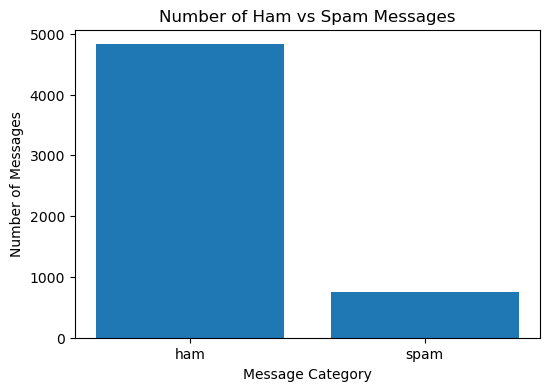

In [11]:
# TASK 2: VISUALIZE DATASET

counts = df["Category"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

plt.title("Number of Ham vs Spam Messages")
plt.xlabel("Message Category")
plt.ylabel("Number of Messages")

plt.show()

In [12]:
# TASK 3: PREPARE DATA

df["Category"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})

X = df["Message"].astype(str)
y = df["Category"]

print("\nCategory Mapping:")
print("Ham = 0")
print("Spam = 1")


Category Mapping:
Ham = 0
Spam = 1


In [13]:
# TASK 4: SPLIT DATASET

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 4457
Testing samples: 1115


In [14]:
# TASK 5: CONVERT TEXT TO NUMBERS

vectorizer = CountVectorizer(stop_words="english")

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("\nText converted into numerical features.")


Text converted into numerical features.


In [15]:
# TASK 6: TRAIN MODEL

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vectorized, y_train)

print("Model training completed!")

Model training completed!


In [16]:
# TASK 7: MAKE PREDICTIONS

predictions = model.predict(X_test_vectorized)

print("\nPredictions:")
print(predictions)


Predictions:
[0 0 0 ... 0 0 0]



Model Accuracy:
0.9748878923766816

Accuracy Percentage:
97.48878923766816 %

Confusion Matrix:
[[965   1]
 [ 27 122]]

Correctly Classified Messages:
1087


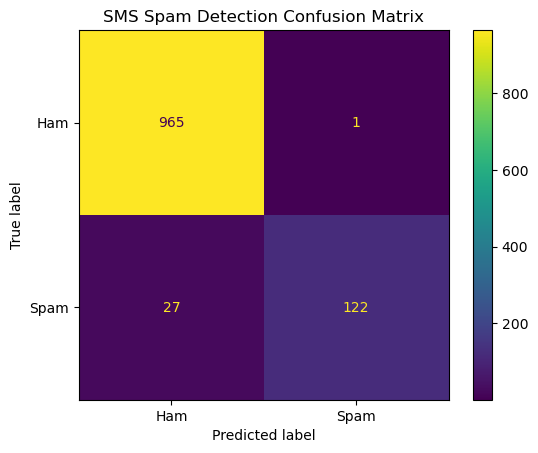

In [17]:
# TASK 8: EVALUATE MODEL

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:")
print(accuracy)

print("\nAccuracy Percentage:")
print(accuracy * 100, "%")


# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:")
print(cm)

print("\nCorrectly Classified Messages:")
print(cm[0,0] + cm[1,1])


# Display Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("SMS Spam Detection Confusion Matrix")
plt.show()

In [18]:
# TASK 9: TEST YOUR OWN SMS

message = input("\nEnter an SMS message: ")

message_vector = vectorizer.transform([message])

prediction = model.predict(message_vector)[0]

if prediction == 0:
    print("📩 HAM MESSAGE")
else:
    print("🚨 SPAM MESSAGE")


Enter an SMS message:  hi


📩 HAM MESSAGE
